In [52]:
import numpy as np
import matplotlib.pyplot as plt


In [53]:
#Read the train dataset
train = np.loadtxt('click.csv', delimiter=',', skiprows=1)
train_x = train[:,0]
train_y = train[:,1]

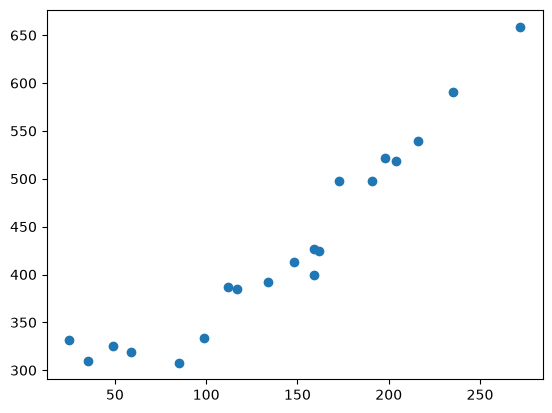

In [54]:
#Draw the picture
plt.plot(train_x, train_y, 'o')
plt.show()

In [55]:
#Parameter initialization
theta0 = np.random.rand()
theta1 = np.random.rand()

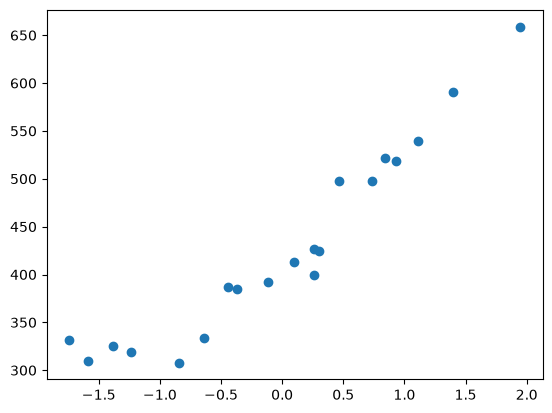

In [56]:
#Prediction function
def f(x):
    return theta0 + theta1 * x

#Objective function
def E(x, y):
    return 0.5 * np.sum((y - f(x)) ** 2)

#Standardization
mu = train_x.mean()
sigma = train_x.std()
def standardize(x):
    return (x - mu) / sigma

train_z = standardize(train_x)
plt.plot(train_z, train_y, 'o')
plt.show()


In [57]:
#Learning rate
ETA = 1e-3

#误差的差值
diff = 1

#更新次数
count = 0

#重复学习
error = E(train_z, train_y)
while diff > 1e-2:
    tmp0 = theta0 - ETA * np.sum(f(train_z) - train_y)
    tmp1 = theta1 - ETA * np.sum((f(train_z) - train_y) * train_z)
    theta0 = tmp0
    theta1 = tmp1
    current_error = E(train_z, train_y)
    diff = error - current_error
    error = current_error
    count += 1
    log = '第{}次: theta0 = {:.3f}, theta1 = {:.3f}, 差值 = {:.4f}'
    print(log.format(count, theta0, theta1, diff))


第1次: theta0 = 8.792, theta1 = 2.114, 差值 = 76300.7378
第2次: theta0 = 17.199, theta1 = 3.941, 差值 = 73279.2285
第3次: theta0 = 25.438, theta1 = 5.732, 差值 = 70377.3711
第4次: theta0 = 33.512, theta1 = 7.487, 差值 = 67590.4272
第5次: theta0 = 41.425, theta1 = 9.206, 差值 = 64913.8463
第6次: theta0 = 49.180, theta1 = 10.892, 差值 = 62343.2580
第7次: theta0 = 56.779, theta1 = 12.544, 差值 = 59874.4650
第8次: theta0 = 64.226, theta1 = 14.162, 差值 = 57503.4361
第9次: theta0 = 71.525, theta1 = 15.749, 差值 = 55226.3001
第10次: theta0 = 78.677, theta1 = 17.303, 差值 = 53039.3386
第11次: theta0 = 85.687, theta1 = 18.827, 差值 = 50938.9808
第12次: theta0 = 92.556, theta1 = 20.320, 差值 = 48921.7971
第13次: theta0 = 99.288, theta1 = 21.783, 差值 = 46984.4940
第14次: theta0 = 105.885, theta1 = 23.217, 差值 = 45123.9080
第15次: theta0 = 112.350, theta1 = 24.622, 差值 = 43337.0013
第16次: theta0 = 118.686, theta1 = 25.999, 差值 = 41620.8560
第17次: theta0 = 124.896, theta1 = 27.349, 差值 = 39972.6701
第18次: theta0 = 130.981, theta1 = 28.671, 差值 = 38389.7524
第1

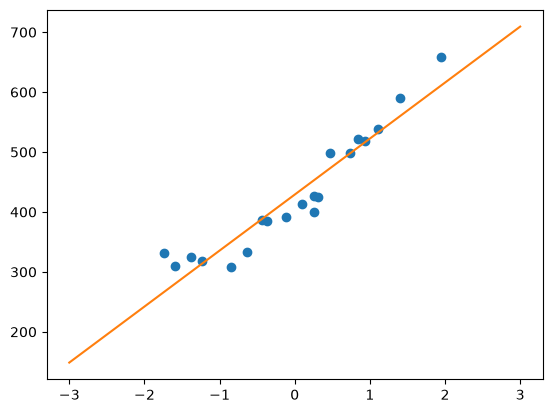

In [58]:
x = np.linspace(-3, 3, 100)
plt.plot(train_z, train_y, 'o')
plt.plot(x, f(x))
plt.show()


In [59]:
f(standardize(100))

np.float64(370.9672100355301)

In [60]:
f(standardize(200))

np.float64(510.4696267361427)

In [61]:
f(standardize(300))

np.float64(649.9720434367553)

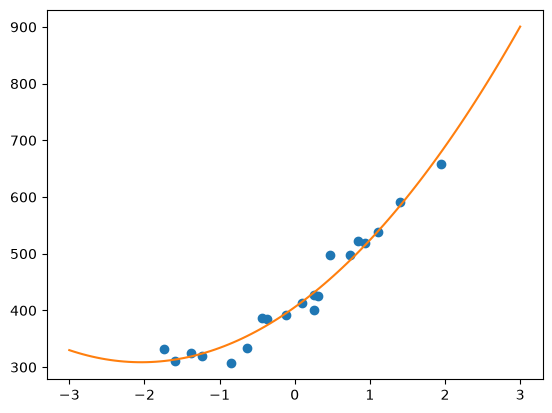

In [62]:
#Parameter initialization
theta = np.random.rand(3)

#Create matrix for train dataset
def to_matrix(x):
    return np.vstack([np.ones(x.shape[0]), x, x ** 2]).T

X = to_matrix(train_z)

#Prediction function
def f(x):
    return np.dot(x, theta)

#误差的差值
diff = 1

#重复学习
error = E(X, train_y)
while diff > 1e-2:
    theta = theta - ETA * np.dot((f(X) - train_y).T, X)
    current_error = E(X, train_y)
    diff = error - current_error
    error = current_error

x = np.linspace(-3, 3, 100)
plt.plot(train_z, train_y, 'o')
plt.plot(x, f(to_matrix(x)))
plt.show()


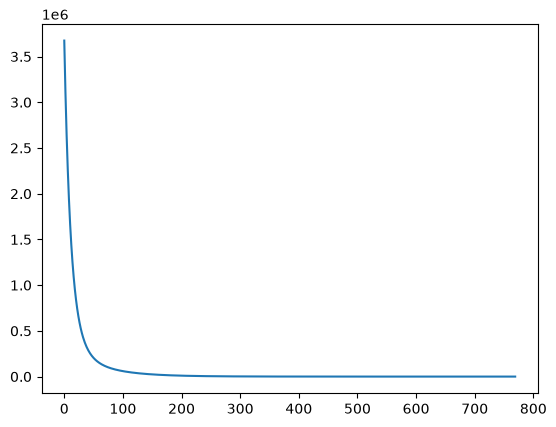

In [63]:
#Mean Square Error
def MSE(x, y):
    return (1 / x.shape[0]) * np.sum(f(x) - y) ** 2

theta = np.random.rand(3)

#The record of MSE
errors = []
diff = 1
errors.append(MSE(X, train_y))

while diff > 1e-2:
    theta = theta - ETA * np.dot(f(X) - train_y, X)
    errors.append(MSE(X, train_y))
    diff = errors[-2] - errors[-1]

#Plot the error curve
x = np.arange(len(errors))
plt.plot(x, errors)
plt.show()

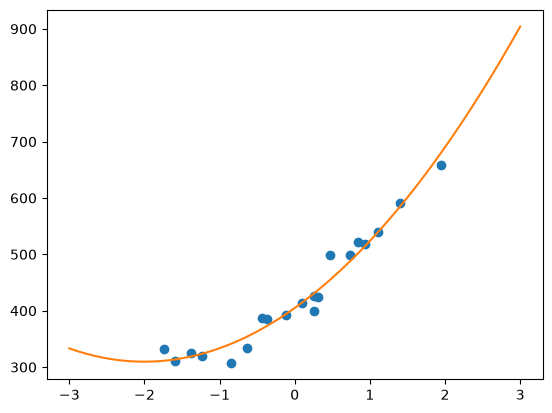

In [64]:
#随机梯度下降法
theta = np.random.rand(3)

#The record of MSE
errors = []
diff = 1
errors.append(MSE(X, train_y))

while diff > 1e-2:
    #为了调整训练数据的顺序，准备随机的序列
    p = np.random.permutation(X.shape[0])
    for x, y in zip(X[p, :], train_y[p]):
        theta = theta - ETA * np.dot(f(x) - y, x)

    #计算与上一次误差的差值
    errors.append(MSE(X, train_y))
    diff = errors[-2] - errors[-1]

x = np.linspace(-3, 3, 100)
plt.plot(train_z, train_y, 'o')
plt.plot(x, f(to_matrix(x)))
plt.show()


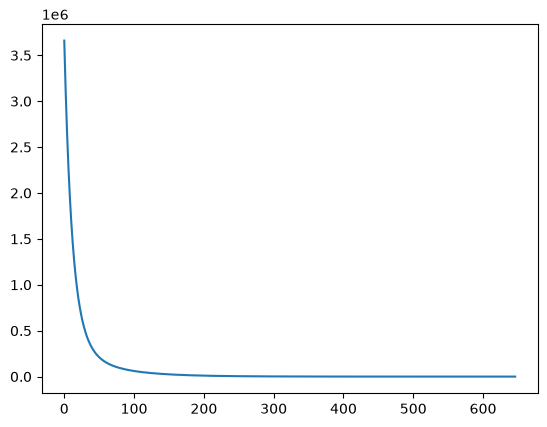

In [65]:
#Plot the error curve
x = np.arange(len(errors))
plt.plot(x, errors)
plt.show()